In [1]:
from src.config import PROCESSED_DATA_DIR, MODELS_DIR

In [2]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
from ultralytics import YOLO

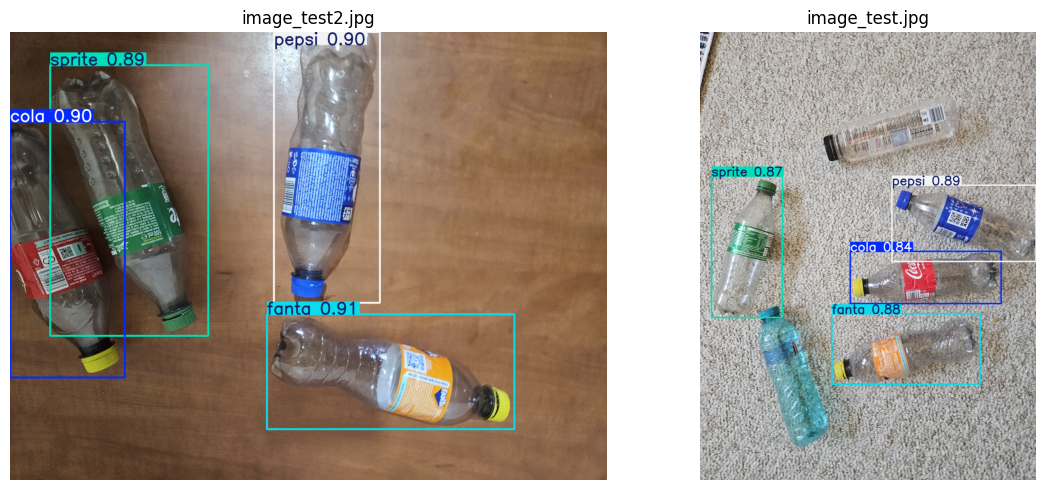

In [ ]:
model = YOLO(model=MODELS_DIR / "best.pt")  # Load the trained model from 'models' directory (change "best.pt" to your actual model filename)

IMAGES_FOLDER = PROCESSED_DATA_DIR / "images" / "test"
VALID_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif') 

def plot_random_detections(model: YOLO, folder_path: Path, num_images: int = 5):
    all_images = [
        f for f in folder_path.iterdir() 
        if f.suffix.lower() in VALID_EXTENSIONS
    ]

    if num_images < 1:
        print("Error: 'num_images' must be at least 1")
        return
    
    if not all_images:
        print(f"No valid images found in {folder_path}")
        return

    num_to_show = min(num_images, len(all_images))
    random_images = random.sample(all_images, num_to_show)
    
    _, axes = plt.subplots(1, num_to_show, figsize=(12, 5))
    
    if num_to_show == 1:
        axes = [axes]

    for i, img_path in enumerate(random_images):
        results = model.predict(img_path, verbose=False)
        annotated_frame = results[0].plot()
        
        img_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(f"{img_path.name}", fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

plot_random_detections(model, IMAGES_FOLDER, num_images=5)  # Adjust num_images to show more or fewer images